# Charge neutrality

We have seen in the previous tutorials that formation energies and concentrations depend on the Fermi level. So how do we compute the concentrations in equilibrium?\
We can assume that, in thermodynamic equilibrium, the net charge if the system is zero (charge neutrality condition). The position of Fermi level (electron chemical potential, $\mu_e$) in thermodynamic equilibrium will be such that the positive and negative charges (electronic + ionic) compensate each other. 
 
$$ \sum_{q,D} q\cdot[D_q] (\mu_e,T) - n_e (\mu_e,T)  + n_h (\mu_e,T) = 0 $$
where $[D_q]$ is the concentration of defect $D$ in charge state $q$, $n_e$ is the concentration of electrons and $n_h$ is the concentration of holes. At a given temperature $T$, we can solve this equation and determine the Fermi level position and the equilibrium concentrations.

In `defermi`, the equilibrium Fermi level can be computed with the `solve_fermi_level` function. Let's see how it works with our usual example.

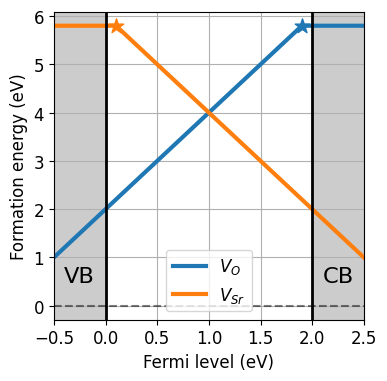

In [1]:
import pandas as pd
from defermi import DefectsAnalysis

bulk_volume = 800 # cubic Amstrong
data = [
{'name': 'Vac_O','charge': 2,'multiplicity': 1,'energy_diff': 7,'bulk_volume': bulk_volume},
{'name': 'Vac_O','charge':0,'multiplicity':1,'energy_diff': 10.8, 'bulk_volume': bulk_volume},
{'name': 'Vac_Sr','charge': -2,'multiplicity': 1,'energy_diff': 8,'bulk_volume': bulk_volume},
{'name': 'Vac_Sr','charge': 0,'multiplicity': 1,'energy_diff': 7.8,'bulk_volume': bulk_volume},
]
df = pd.DataFrame(data)
da = DefectsAnalysis.from_dataframe(df,band_gap=2.0,vbm=0.0)

chempots = {'O':-5,'Sr':-2}
da.plot_formation_energies(chempots,figsize=(4,4));

In [12]:
# Find equilibrium Fermi level solving charge neutrality
da.solve_fermi_level(
                    chemical_potentials=chempots,
                    bulk_dos={'m_eff_e':0.5,'m_eff_h':0.4},
                    temperature=1000)

0.9855782323977027

The `bulk_dos` argument is needed for the calculation of the electronic carriers (electrons and holes), which is the focus of the next section.

### Electronic carriers

The concentrations of intrinsic carriers are derived by integrating the number of unoccupied states up to the VBM ($\mathrm{E_{VBM}}$) for holes:
$$n_{h} = \int_{-\infty}^{E_{VBM}} D(\epsilon)[1 - f(\epsilon)] d\epsilon $$

and the number of occupied states from the CBM ($\mathrm{E_{CBM}}$) for electrons:
$$ n_{e} = \int_{E_{CBM}}^{+\infty} D(\epsilon) f(\epsilon) d\epsilon $$

We can also express it in terms of effective masses: 
$$
n_e = N_c \, e^{-\frac{E_c - E_F}{k_B T}} \: , \: n_h = N_v \, e^{-\frac{E_F - E_v}{k_B T}}
$$

$$
N_c = 2 \left( \frac{2\pi m_e^{\ast} k_B T}{h^2} \right)^{3/2} \: , \: N_v = 2 \left( \frac{2\pi m_h^{\ast} k_B T}{h^2} \right)^{3/2}
$$

#### DOS

In `defermi`, both the numerical integration using the density of states (DOS, $D(\epsilon)$) and the effective mass approximation are available. If the DOS is available from a VASP calculation, the easiest way is to pass a pymatgen `Dos` (or `FermiDos` or `CompleteDos`) object. If not available, it also can be pulled from the [Materials Project Database](https://next-gen.materialsproject.org/).

In [9]:
from defermi.tools.materials_project import MPDatabase

bulk_dos = MPDatabase().get_dos_from_stable_composition('SrO')
bulk_dos

Retrieving ThermoDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Retrieving ElectronicStructureDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

If a DOS from any other DFT code is available, you can pass it as a `dict`, with the following keys and values:
- `"energies"`: `list` or `np.array` with energy values
- `"densities"`: `list` or `np.array` with total density values
- `"structure"`: pymatgen `Structure` of the material, needed for DOS volume and charge normalization

In both cases, the integration is carried out using pymatgen's `FermiDos` class.

#### Effective masses

If the DOS is not available, you can provide the effective masses of electrons and holes as a dictionary: `{"m_eff_e":value, "m_eff_h":value}`, as in the previous example. The number of carriers is computed as explained above.

#### Chemical potentials

The chemical potentials are defined in the same way as for [Formation energies](./formation_energies.ipynb) (with the possibility to pull values from the MP database).

#### Self-consistent solution

The charge neutrality equation is solved using scipy's `bisect` method, with $\epsilon_F$ range $[-1,E_g + 1]$, with $\epsilon_F$ set to zero at $E_{\mathrm{VBM}}$. 